## Methode STIT de Klatt et Lotz


Persistence of asymptotic variance under transport: \
from hyperfluctuation to stealthy hyperuniformity \

cf Page 6 du papier:
https://arxiv.org/pdf/2605.22803


 STIT tessellations = stable with respect to iterations

In [18]:
import numpy as np


# ------------------------------------------------------------
# Aire spécialisée quadrilatère
# ------------------------------------------------------------

def quad_signed_area(q):
    x0, y0 = q[..., 0, 0], q[..., 0, 1]
    x1, y1 = q[..., 1, 0], q[..., 1, 1]
    x2, y2 = q[..., 2, 0], q[..., 2, 1]
    x3, y3 = q[..., 3, 0], q[..., 3, 1]

    return 0.5 * (
        x0 * y1 - x1 * y0
        + x1 * y2 - x2 * y1
        + x2 * y3 - x3 * y2
        + x3 * y0 - x0 * y3
    )


def area4(P0, P1, P2, P3):
    return 0.5 * (
        P0[..., 0] * P1[..., 1] - P1[..., 0] * P0[..., 1]
        + P1[..., 0] * P2[..., 1] - P2[..., 0] * P1[..., 1]
        + P2[..., 0] * P3[..., 1] - P3[..., 0] * P2[..., 1]
        + P3[..., 0] * P0[..., 1] - P0[..., 0] * P3[..., 1]
    )


# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

def _attempt(quads, pool, rng, n_iter=40, eps=1e-9):

    B = quads.shape[0]

    A = quads[:, 0]
    Bv = quads[:, 1]
    C = quads[:, 2]
    D = quads[:, 3]

    total_area = quad_signed_area(quads)
    target = (total_area * 0.5)[:, None]

    theta = rng.uniform(0.0, np.pi, size=(B, pool))

    sin_t = np.sin(theta)
    cos_t = np.cos(theta)

    nx = -sin_t
    ny = cos_t

    # --------------------------------------------------------
    # projections
    # --------------------------------------------------------

    def lvl(P):
        return (
            P[:, None, 0] * nx
            + P[:, None, 1] * ny
        )

    hA = lvl(A)
    hB = lvl(Bv)
    hC = lvl(C)
    hD = lvl(D)

    h = np.stack((hA, hB, hC, hD), axis=-1)

    h_sorted = np.sort(h, axis=-1)

    l1 = h_sorted[..., 1]
    l2 = h_sorted[..., 2]

    is_bottom2 = h <= l1[..., None]

    cross_DA_BC = (
        (is_bottom2[..., 0] & is_bottom2[..., 1])
        |
        (is_bottom2[..., 2] & is_bottom2[..., 3])
    )

    # --------------------------------------------------------
    # interpolation
    # --------------------------------------------------------

    def edge_point(V1, V2, h1, h2, t):

        denom = h2 - h1
        denom = np.where(np.abs(denom) < eps, eps, denom)

        alpha = (t - h1) / denom

        return (
            V1[:, None, :]
            + alpha[..., None] * (V2 - V1)[:, None, :]
        )

    # broadcasts réutilisés
    Ab = np.broadcast_to(A[:, None, :], (B, pool, 2))
    Bb = np.broadcast_to(Bv[:, None, :], (B, pool, 2))
    Cb = np.broadcast_to(C[:, None, :], (B, pool, 2))
    Db = np.broadcast_to(D[:, None, :], (B, pool, 2))

    def area_at(t):

        P_AB = edge_point(A, Bv, hA, hB, t)
        P_BC = edge_point(Bv, C, hB, hC, t)
        P_CD = edge_point(C, D, hC, hD, t)
        P_DA = edge_point(D, A, hD, hA, t)

        area_DA_BC = area4(
            Ab,
            Bb,
            P_BC,
            P_DA,
        )

        area_AB_CD = area4(
            P_AB,
            Bb,
            Cb,
            P_CD,
        )

        area = np.where(
            cross_DA_BC,
            area_DA_BC,
            area_AB_CD,
        )

        return area, (P_AB, P_BC, P_CD, P_DA)

    # --------------------------------------------------------
    # recherche intervalle
    # --------------------------------------------------------

    area_l1, _ = area_at(l1)
    area_l2, _ = area_at(l2)

    f_l1 = area_l1 - target
    f_l2 = area_l2 - target

    pool_ok = (f_l1 * f_l2) <= 0

    # --------------------------------------------------------
    # dichotomie
    # --------------------------------------------------------

    lo = l1.copy()
    hi = l2.copy()

    f_lo = f_l1.copy()

    mid = np.empty_like(lo)

    for _ in range(n_iter):

        np.add(lo, hi, out=mid)
        mid *= 0.5

        f_mid, _ = area_at(mid)
        f_mid -= target

        same_sign = np.signbit(f_mid) == np.signbit(f_lo)

        lo = np.where(same_sign, mid, lo)
        hi = np.where(same_sign, hi, mid)

        f_lo = np.where(same_sign, f_mid, f_lo)

    t_star = 0.5 * (lo + hi)

    # --------------------------------------------------------
    # géométrie finale
    # --------------------------------------------------------

    _, (P_AB, P_BC, P_CD, P_DA) = area_at(t_star)

    piece1_DABC = np.stack(
        (Ab, Bb, P_BC, P_DA),
        axis=-2,
    )

    piece2_DABC = np.stack(
        (P_BC, Cb, Db, P_DA),
        axis=-2,
    )

    piece1_ABCD = np.stack(
        (P_AB, Bb, Cb, P_CD),
        axis=-2,
    )

    piece2_ABCD = np.stack(
        (Ab, P_AB, P_CD, Db),
        axis=-2,
    )

    mask = cross_DA_BC[..., None, None]

    piece1 = np.where(mask, piece1_DABC, piece1_ABCD)
    piece2 = np.where(mask, piece2_DABC, piece2_ABCD)

    ok = np.any(pool_ok, axis=1)

    idx_sel = np.argmax(pool_ok, axis=1)

    piece1_sel = np.take_along_axis(
        piece1,
        idx_sel[:, None, None, None],
        axis=1,
    )[:, 0]

    piece2_sel = np.take_along_axis(
        piece2,
        idx_sel[:, None, None, None],
        axis=1,
    )[:, 0]

    return piece1_sel, piece2_sel, ok


def fair_random_split(
    quads,
    pool=30,
    n_iter=40,
    rng=None,
    max_retries=5,
    growth=4,
):

    rng = np.random.default_rng() if rng is None else rng

    B = quads.shape[0]

    piece1 = np.empty((B, 4, 2), dtype=quads.dtype)
    piece2 = np.empty((B, 4, 2), dtype=quads.dtype)

    resolved = np.zeros(B, dtype=bool)

    remaining_idx = np.arange(B)

    cur_pool = pool

    for _ in range(max_retries + 1):

        if len(remaining_idx) == 0:
            break

        p1, p2, ok = _attempt(
            quads[remaining_idx],
            cur_pool,
            rng,
            n_iter=n_iter,
        )

        good = remaining_idx[ok]

        piece1[good] = p1[ok]
        piece2[good] = p2[ok]

        resolved[good] = True

        remaining_idx = remaining_idx[~ok]

        cur_pool *= growth

    if len(remaining_idx):

        raise RuntimeError(
            f"no fair quad/quad split found for "
            f"{len(remaining_idx)} polygon(s)"
        )

    return np.concatenate(
        (piece1, piece2),
        axis=0,
    )

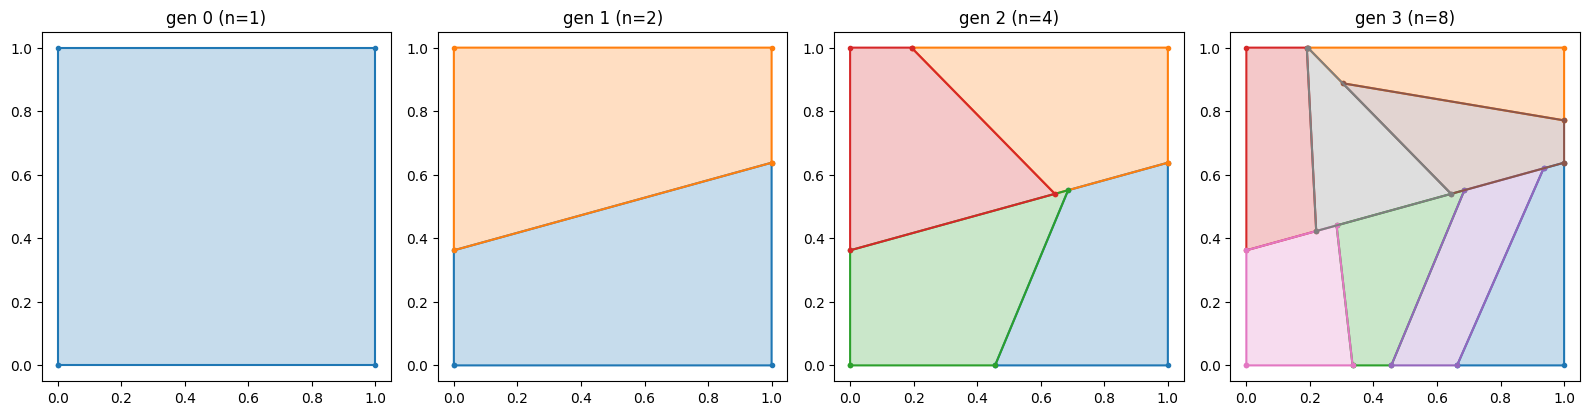

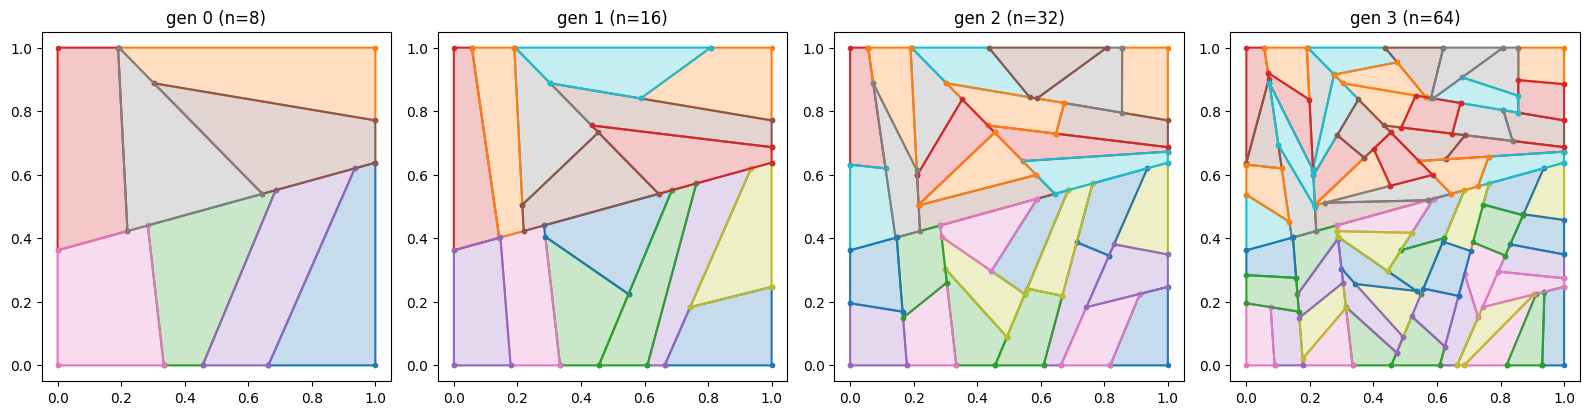

In [19]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(3)
quad = np.array([[[0,0],[1.0,0.0],[1.0,1.0],[0.0,1.0]]], dtype=float)

cur = quad

for _ in range(2):

    fig, axes = plt.subplots(1, 4, figsize=(16,4))
    for ax, gen in zip(axes, range(4)):
        for q in cur:
            poly = np.vstack([q, q[0]])
            ax.plot(poly[:,0], poly[:,1], '-o', ms=3)
            ax.fill(q[:,0], q[:,1], alpha=0.25)
        ax.set_title(f"gen {gen} (n={len(cur)})")
        ax.set_aspect('equal')
        if gen < 3:
            cur = fair_random_split(cur, pool=30, rng=rng)

    plt.tight_layout()
    plt.show()

In [25]:
cur = quad

for _ in range(17):
    cur = fair_random_split(cur, pool=30, rng=rng)
    print(len(cur))

x = cur.mean(axis = 1)

2
4
8
16
32
64
128
256
512
1024
2048
4096
8192
16384
32768
65536
131072


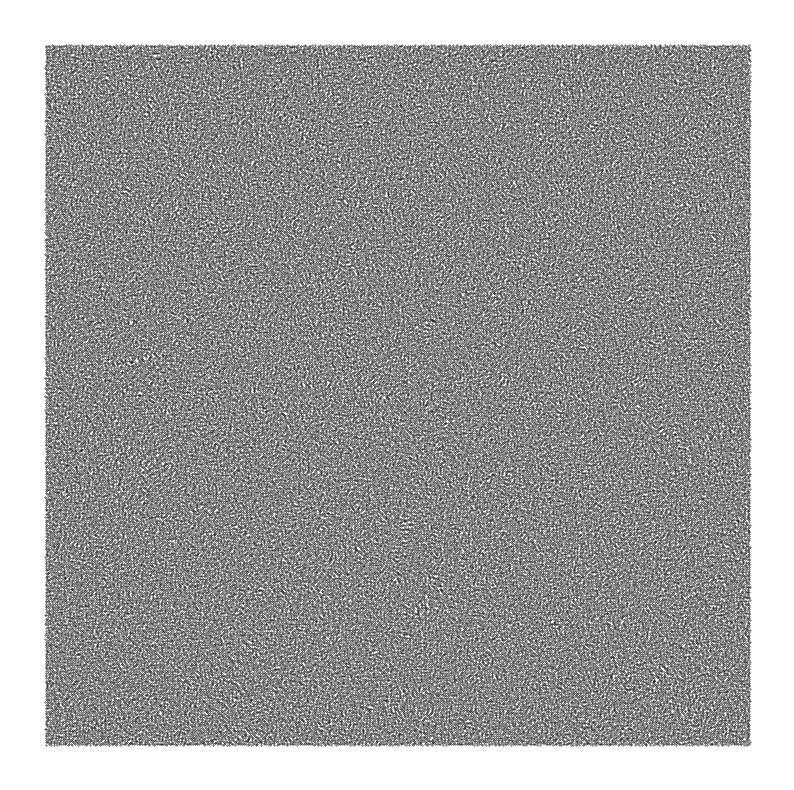

In [27]:
plt.figure(figsize=(10, 10))
plt.scatter(x[:, 0], x[:, 1], color = "black", s = 0.1)
plt.axis("off")
plt.show()

In [28]:
!pip install blue_sampler

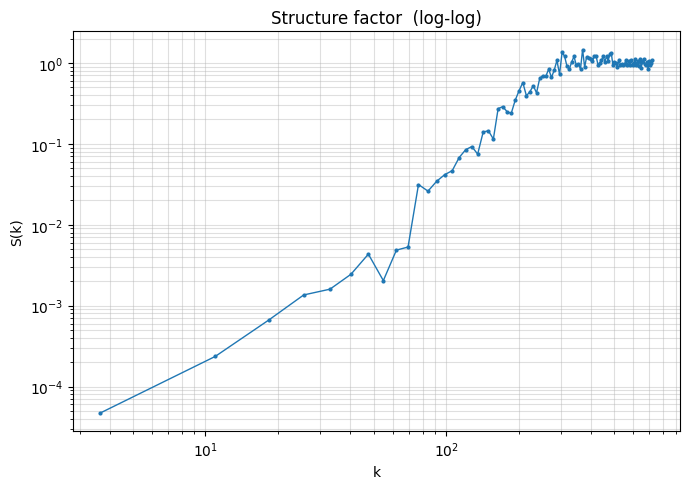

In [29]:
import blue_sampler as blue

_ = blue.plot_structure_factor(x, resolution = 50)